# COMP360(A) Introduction to Artificial Intelligence
## Project Title: AI-Powered gamified learning platform for students (grade 3-7)

Group Members:

•	Musfira Sehar 280048443

•	Amzi Asif 281133626


# 1. Dataset Generation

## Imports

In [36]:
import pandas as pd     #For saving dataset as CSV
import numpy as np      #For generating random numbers

np.random.seed(42)      #makes random data reproducible

## Basic Students Info

In [37]:
n = 200     # number of students

student_ids = [f"S{str(i).zfill(3)}" for i in range(1, n+1)]
grade_levels = np.random.randint(3, 8, n)

## Feature Generation

In [38]:
quiz_scores = np.random.randint(20, 101, n)
time_spent = np.round(np.random.uniform(0.5, 10.0, n), 1)
attempts = np.random.randint(1, 6, n)
hints_used = np.random.randint(0, 11, n)
streak_days = np.random.randint(0, 31, n)
assignments_completed = np.random.randint(10, 101, n)

## Labeling Logic

In [39]:
performance_score = (
    quiz_scores * 0.4 +
    assignments_completed * 0.3 +
    (streak_days / 30 * 100) * 0.2 +
    (time_spent / 10 * 100) * 0.1
)

def assign_label(score):
    if score <= 50:
        return "Low"
    elif score <= 65:
        return "Medium"
    else:
        return "High"

labels = [assign_label(s) for s in performance_score]

"Initial labeling thresholds produced a class imbalance. Thresholds were adjusted to produce a more balanced distribution suitable for classification."

## Build and Save the DataFrame

In [40]:
df = pd.DataFrame({
    "student_id": student_ids,
    "grade_level": grade_levels,
    "quiz_score": quiz_scores,
    "time_spent_hrs": time_spent,
    "attempts": attempts,
    "hints_used": hints_used,
    "streak_days": streak_days,
    "assignments_completed": assignments_completed,
    "performance_label": labels
})

import os
df.to_csv(os.path.join(os.getcwd(), "student_data.csv"), index=False)
print("Saved to:", os.getcwd())
print(df.head())
print(df["performance_label"].value_counts())

Saved to: /content
  student_id  grade_level  quiz_score  time_spent_hrs  attempts  hints_used  \
0       S001            6          89             5.9         4           3   
1       S002            7          30             2.0         1           0   
2       S003            5          35             1.6         5           0   
3       S004            7          92             3.7         5           9   
4       S005            7          78             1.4         3           5   

   streak_days  assignments_completed performance_label  
0           11                     46            Medium  
1           26                     84            Medium  
2           18                     79            Medium  
3           21                     27            Medium  
4           23                     94              High  
performance_label
Medium    76
Low       74
High      50
Name: count, dtype: int64


# 2. Data Exploration: EDA-Exploratory Data Analysis

## Loading Basic info

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student_data.csv")

print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (200, 9)

Column Types:
 student_id                object
grade_level                int64
quiz_score                 int64
time_spent_hrs           float64
attempts                   int64
hints_used                 int64
streak_days                int64
assignments_completed      int64
performance_label         object
dtype: object

Missing Values:
 student_id               0
grade_level              0
quiz_score               0
time_spent_hrs           0
attempts                 0
hints_used               0
streak_days              0
assignments_completed    0
performance_label        0
dtype: int64

Duplicate Rows: 0


## Statistical Summary

In [42]:
print(df.describe())

       grade_level  quiz_score  time_spent_hrs    attempts  hints_used  \
count   200.000000  200.000000      200.000000  200.000000  200.000000   
mean      5.000000   57.390000        5.254500    2.950000    5.145000   
std       1.417762   21.780954        2.761105    1.413325    3.183496   
min       3.000000   20.000000        0.600000    1.000000    0.000000   
25%       4.000000   38.750000        2.900000    2.000000    3.000000   
50%       5.000000   56.000000        5.200000    3.000000    5.000000   
75%       6.000000   77.000000        7.500000    4.000000    8.000000   
max       7.000000   99.000000       10.000000    5.000000   10.000000   

       streak_days  assignments_completed  
count   200.000000             200.000000  
mean     15.650000              53.385000  
std       9.016317              25.322379  
min       0.000000              10.000000  
25%       7.750000              32.750000  
50%      17.000000              51.000000  
75%      22.250000       

## Label Distribution Plot

/tmp/ipykernel_1905/763968252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="performance_label", data=df,


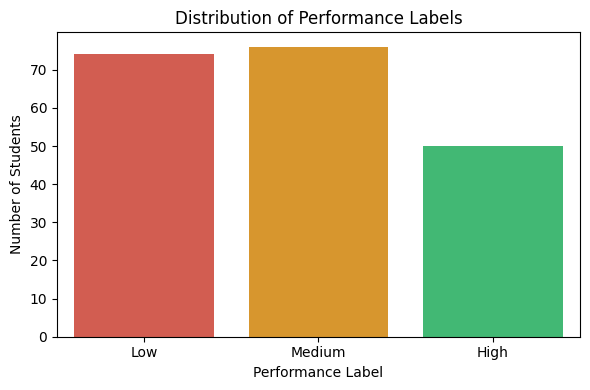

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(x="performance_label", data=df,
              order=["Low", "Medium", "High"],
              palette=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Distribution of Performance Labels")
plt.xlabel("Performance Label")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("label_distribution.png")
plt.show()

## Feature vs Label

/tmp/ipykernel_1905/751886591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="performance_label", y=feature, data=df,
/tmp/ipykernel_1905/751886591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="performance_label", y=feature, data=df,
/tmp/ipykernel_1905/751886591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="performance_label", y=feature, data=df,
/tmp/ipykernel_1905/751886591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

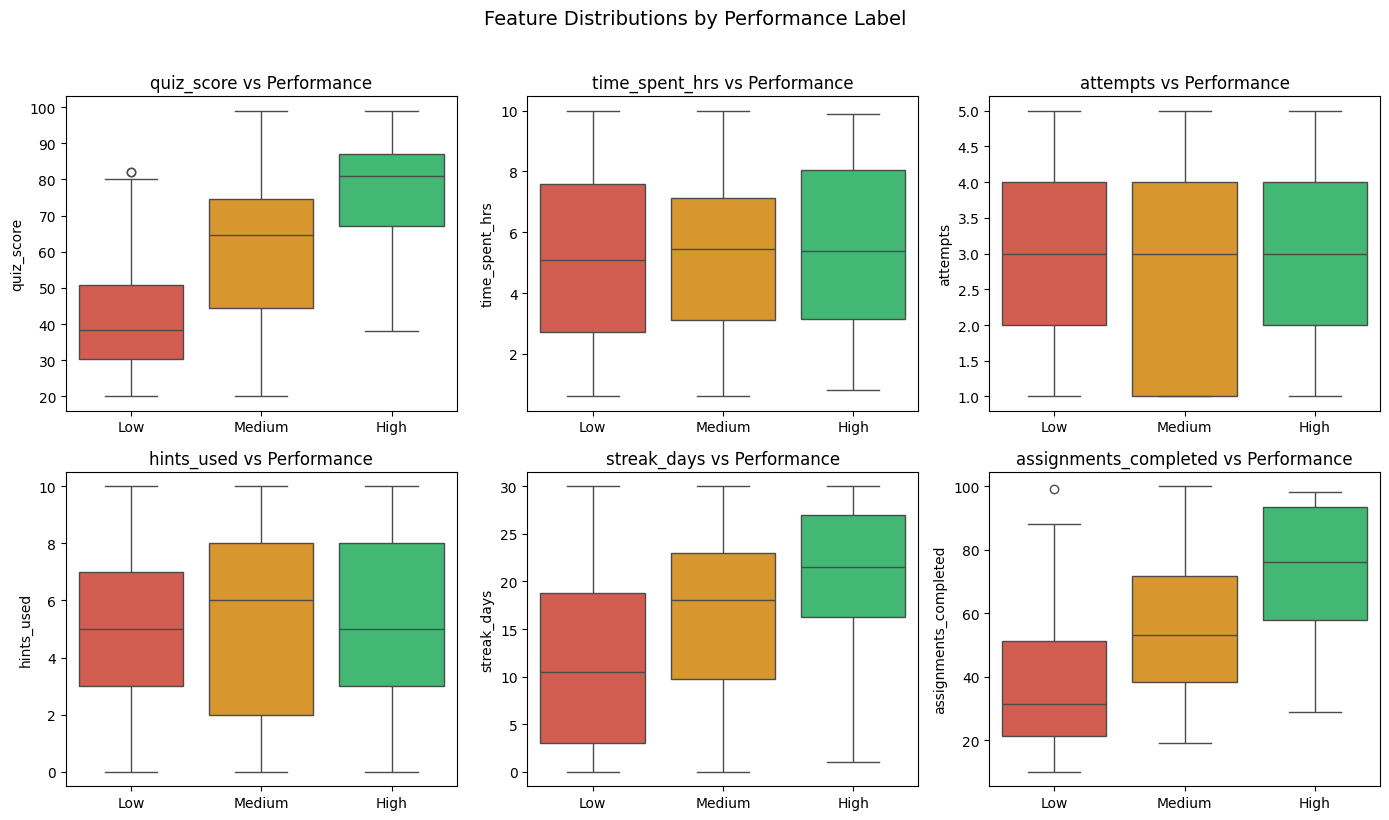

In [44]:
features = ["quiz_score", "time_spent_hrs", "attempts",
            "hints_used", "streak_days", "assignments_completed"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x="performance_label", y=feature, data=df,
                order=["Low", "Medium", "High"],
                palette=["#e74c3c", "#f39c12", "#2ecc71"],
                ax=axes[i])
    axes[i].set_title(f"{feature} vs Performance")
    axes[i].set_xlabel("")

plt.suptitle("Feature Distributions by Performance Label",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("feature_vs_label.png")
plt.show()

# 3. Model Traning


Full Dataset (200 rows)

        ↓

   Split into two parts

        ↓
        
Training Set (160 rows)  →  Random Forest learns from this

Testing Set  (40 rows)   →  We test how well it learned on this

We will use 80% for training, 20% for testing.

200 students × 0.8 = 160 training

200 students × 0.2 = 40  testing

## Prepare Data

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Select features and target
X = df[["quiz_score", "time_spent_hrs", "attempts",
        "hints_used", "streak_days", "assignments_completed"]]
y = df["performance_label"]

# Encode labels (Low=0, Medium=1, High=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features shape:", X.shape)
print("Labels:", le.classes_)

Features shape: (200, 6)
Labels: ['High' 'Low' 'Medium']


1. X — input features (everything the model learns from)

2. y — target label (what the model predicts)

3. LabelEncoder — converts Low/Medium/High into 0/1/2 because ML models work with numbers, not text

4. le.classes_ — shows the mapping so you know which number means what

## Split the Data

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


1. test_size=0.2 — 80% train, 20% test

2. random_state=42 — same seed as before, makes split reproducible

3. stratify= y_encoded — It ensures your Low/Medium/High ratio is preserved in both train and test sets. Without this, you might accidentally get all your "High" students in training and none in testing.

## Train The Model

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model training complete!")
print("Number of trees:", rf_model.n_estimators)

Model training complete!
Number of trees: 100


1. n_estimators=100 — builds 100 decision trees

2. .fit() — this is where the actual learning happens

what's happening underneath: 100 trees, random subsets, majority voting

## Save The Model

In [48]:
import joblib

joblib.dump(rf_model, "model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model saved as model.pkl")
print("Label encoder saved as label_encoder.pkl")

Model saved as model.pkl
Label encoder saved as label_encoder.pkl


1. Saves your trained model to a file so the Streamlit app can load it later without retraining

2. label_encoder is saved too because the app needs to convert predictions back from numbers to Low/Medium/High

3. .pkl is like a snapshot of your trained model

### Random Forest just studied 160 students, built 100 decision trees, and is now ready to predict the performance level of any new student it has never seen before.

# 4. Evaluation

## Basic Accuracy

In [49]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 72.50%


1. rf_model.predict(X_test) — feeds the 40 unseen test students into the model

2. Model predicts 0, 1, or 2 for each student

3. Accuracy tells you what percentage it got right overall

## Full Classification Report

In [50]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=le.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.80      0.84        10
         Low       0.73      0.73      0.73        15
      Medium       0.62      0.67      0.65        15

    accuracy                           0.72        40
   macro avg       0.75      0.73      0.74        40
weighted avg       0.73      0.72      0.73        40



1. Prints Precision, Recall and F1-Score for each class separately

2. target_names=le.classes_ converts 0/1/2 back to High/Low/Medium in the output

3. a row for each class and an overall average is shown at the bottom

## Confusion Matrix

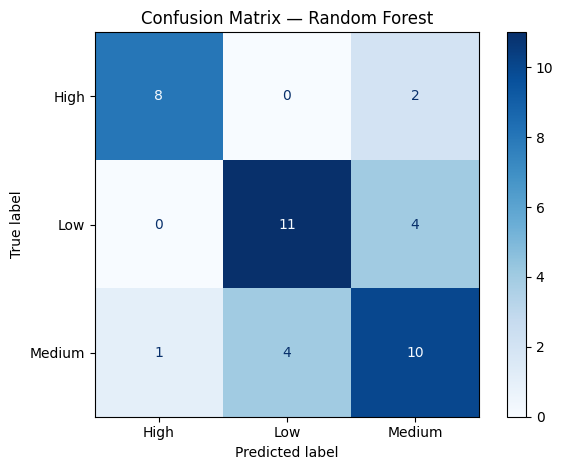

In [51]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

#### Creates a grid showing:
1. predicted vs actual labels
2. Diagonal = correct predictions
3. Off-diagonal = mistakes

Numbers on the diagonal should be the highest.

## Feature Importance

/tmp/ipykernel_1905/879613073.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names,


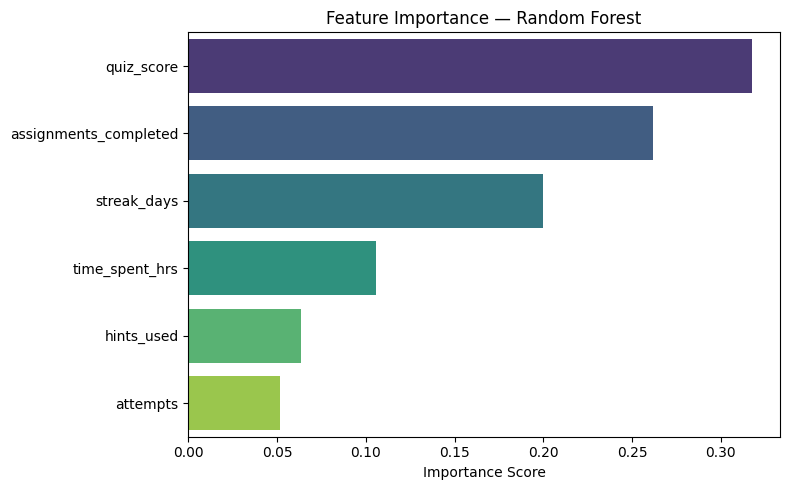

In [52]:
feature_names = ["quiz_score", "time_spent_hrs", "attempts",
                 "hints_used", "streak_days", "assignments_completed"]

importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=feature_names,
            palette="viridis",
            order=[feature_names[i] for i in
                   importances.argsort()[::-1]])
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

1. Shows which features the Random Forest relied on most when making decisions

2. Higher bar = more influential feature

3. If you already know quiz_score and assignments_completed should dominate since they had the highest weights in your labeling formula